In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# 1. Imports
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# =========================
# 2. Paths
# =========================

BASE_DATA_DIR = "/content/drive/MyDrive/Senior_Project/00_Data/cleaned/Final_Short_Form"

OUT_DIR = "/content/drive/MyDrive/Senior_Project/03_Results/Fusion"
os.makedirs(OUT_DIR, exist_ok=True)

FEATURE_PATHS = {
    "liar": {
        "train": f"{BASE_DATA_DIR}/LIAR/train_liar.csv",
        "test": f"{BASE_DATA_DIR}/LIAR/test_liar.csv",
    },
    "covid": {
        "train": f"{BASE_DATA_DIR}/COVID/train_covid.csv",
        "test": f"{BASE_DATA_DIR}/COVID/test_covid.csv",
    },
    "sensational": {
        "train": f"{BASE_DATA_DIR}/Sensational/train_sensational.csv",
        "test": f"{BASE_DATA_DIR}/Sensational/test_sensational.csv",
    },
    "baseline": {
        "train": f"{BASE_DATA_DIR}/LIAR+COVID/train_liar_covid.csv",
        "test": f"{BASE_DATA_DIR}/LIAR+COVID/test_liar_covid.csv",
    },
    "combined": {
        "train": f"{BASE_DATA_DIR}/Combined/train_combined.csv",
        "test": f"{BASE_DATA_DIR}/Combined/test_combined.csv",
    }
}

In [ ]:
# =========================
# 3. BERT probability paths
# =========================
BERT_DIR = "/content/drive/MyDrive/Senior_Project/03_Results/BERT/Final_Short_Form_Probs"

BERT_PATHS = {
    "baseline_model": {
        "train": {
            "baseline": f"{BERT_DIR}/bert_probs_baseline_model_on_liar_covid_train.csv",
        },
        "test": {
            "liar": f"{BERT_DIR}/bert_probs_baseline_model_on_liar_test.csv",
            "covid": f"{BERT_DIR}/bert_probs_baseline_model_on_covid_test.csv",
            "sensational": f"{BERT_DIR}/bert_probs_baseline_model_on_sensational_test.csv",
            "baseline": f"{BERT_DIR}/bert_probs_baseline_model_on_liar_covid_test.csv",
            "combined": f"{BERT_DIR}/bert_probs_baseline_model_on_combined_test.csv",
        }
    },

    "combined_model": {
        "train": {
            "combined": f"{BERT_DIR}/bert_probs_full_model_on_combined_train.csv",
        },
        "test": {
            "liar": f"{BERT_DIR}/bert_probs_full_model_on_liar_test.csv",
            "covid": f"{BERT_DIR}/bert_probs_full_model_on_covid_test.csv",
            "sensational": f"{BERT_DIR}/bert_probs_full_model_on_sensational_test.csv",
            "baseline": f"{BERT_DIR}/bert_probs_full_model_on_liar_covid_test.csv",
            "combined": f"{BERT_DIR}/bert_probs_full_model_on_combined_test.csv",
        }
    }
}

In [ ]:
# =========================
# 4. Feature columns
# =========================

vader_cols = [
    "vader_neg",
    "vader_neu",
    "vader_pos",
    "vader_compound"
]

rhetoric_cols = [
    "word_count",
    "char_count",
    "exclamation_count",
    "question_count",
    "all_caps_count",
    "certainty_count",
    "urgency_count",
    "attack_count",
    "second_person_count"
]

fusion_feature_cols = [
    "bert_prob_fake"
] + vader_cols + rhetoric_cols

In [ ]:
# =========================
# 5. Helper functions
# =========================

def get_id_col(df):
    if "combined_ID" in df.columns:
        return "combined_ID"
    elif "liar_covid_ID" in df.columns:
        return "liar_covid_ID"
    elif "ID" in df.columns:
        return "ID"
    elif "id" in df.columns:
        return "id"
    else:
        raise ValueError(f"No ID column found. Columns: {df.columns.tolist()}")


def load_and_merge_features_with_bert(feature_path, bert_path, dataset_name, model_name, split_name):
    feature_df = pd.read_csv(feature_path)
    bert_df = pd.read_csv(bert_path)

    feature_id = get_id_col(feature_df)
    bert_id = get_id_col(bert_df)

    print("\n" + "=" * 80)
    print(f"Merging {model_name} | {dataset_name} | {split_name}")
    print("Feature path:", feature_path)
    print("BERT path:", bert_path)
    print("Feature ID:", feature_id)
    print("BERT ID:", bert_id)
    print("Feature rows:", len(feature_df))
    print("BERT rows:", len(bert_df))

    if "bert_prob_fake" not in bert_df.columns:
        raise ValueError(f"Missing bert_prob_fake in {bert_path}")

    feature_ids = set(feature_df[feature_id])
    bert_ids = set(bert_df[bert_id])

    only_feature = feature_ids - bert_ids
    only_bert = bert_ids - feature_ids

    print("IDs in both:", len(feature_ids & bert_ids))
    print("Only in feature:", len(only_feature))
    print("Only in BERT:", len(only_bert))

    assert len(only_feature) == 0, f"Feature IDs missing from BERT for {dataset_name} {split_name}"
    assert len(only_bert) == 0, f"BERT IDs missing from feature file for {dataset_name} {split_name}"

    bert_small = bert_df[[bert_id, "bert_prob_fake"]].copy()

    merged = feature_df.merge(
        bert_small,
        left_on=feature_id,
        right_on=bert_id,
        how="inner"
    )

    if bert_id != feature_id and bert_id in merged.columns:
        merged = merged.drop(columns=[bert_id])

    print("Merged rows:", len(merged))

    assert len(merged) == len(feature_df), "Merged rows do not match feature rows"
    assert merged["bert_prob_fake"].notna().all(), "Missing BERT probabilities after merge"

    missing_features = [col for col in fusion_feature_cols if col not in merged.columns]
    if missing_features:
        raise ValueError(f"Missing fusion features: {missing_features}")

    return merged


def evaluate_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [ ]:
# =========================
# 6. Define fusion models
# =========================

fusion_models = {
    "Fusion_LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),

    "Fusion_RF": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        max_depth=None
    )
}

In [ ]:
from sklearn.base import clone

def run_fusion_experiment(
    experiment_name,
    bert_model_name,
    train_dataset_name,
    test_dataset_names
):
    print("\n" + "#" * 90)
    print("Running fusion experiment:", experiment_name)
    print("BERT model:", bert_model_name)
    print("Train dataset:", train_dataset_name)
    print("Test datasets:", test_dataset_names)

    # Load + merge train once
    train_feature_path = FEATURE_PATHS[train_dataset_name]["train"]
    train_bert_path = BERT_PATHS[bert_model_name]["train"][train_dataset_name]

    train_df = load_and_merge_features_with_bert(
        feature_path=train_feature_path,
        bert_path=train_bert_path,
        dataset_name=train_dataset_name,
        model_name=bert_model_name,
        split_name="train"
    )

    X_train = train_df[fusion_feature_cols].copy()
    y_train = train_df["is_fake"].astype(int)

    experiment_results = []
    merged_test_outputs = {}

    # Train each fusion model ONCE
    trained_models = {}

    for fusion_model_name, base_model in fusion_models.items():
        print(f"\nTraining {fusion_model_name} once on {train_dataset_name}...")
        model = clone(base_model)
        model.fit(X_train, y_train)
        trained_models[fusion_model_name] = model

    # Then reuse trained models on all test sets
    for test_dataset_name in test_dataset_names:
        test_feature_path = FEATURE_PATHS[test_dataset_name]["test"]
        test_bert_path = BERT_PATHS[bert_model_name]["test"][test_dataset_name]

        test_df = load_and_merge_features_with_bert(
            feature_path=test_feature_path,
            bert_path=test_bert_path,
            dataset_name=test_dataset_name,
            model_name=bert_model_name,
            split_name="test"
        )

        X_test = test_df[fusion_feature_cols].copy()
        y_test = test_df["is_fake"].astype(int)

        for fusion_model_name, model in trained_models.items():
            y_pred = model.predict(X_test)

            metrics = evaluate_model(y_test, y_pred)

            result = {
                "experiment": experiment_name,
                "bert_model": bert_model_name,
                "train_dataset": train_dataset_name,
                "test_dataset": test_dataset_name,
                "fusion_model": fusion_model_name,
                "train_rows": len(train_df),
                "test_rows": len(test_df),
                **metrics
            }

            experiment_results.append(result)

            print("\n--- Result ---")
            print(result)

            pred_col = f"{fusion_model_name}_pred"
            test_df[pred_col] = y_pred

        merged_test_outputs[test_dataset_name] = test_df.copy()

    return experiment_results, merged_test_outputs, trained_models

In [ ]:
# =========================
# 8. Run experiments
# =========================

all_fusion_results = []
all_merged_outputs = {}

# Experiment 1: baseline fusion
# Train on LIAR+COVID using baseline_model probabilities
baseline_results, baseline_outputs, baseline_trained_models = run_fusion_experiment(
    experiment_name="baseline_fusion",
    bert_model_name="baseline_model",
    train_dataset_name="baseline",
    test_dataset_names=[
        "liar",
        "covid",
        "baseline",
        "sensational",
        "combined"
    ]
)

all_fusion_results.extend(baseline_results)
all_merged_outputs["baseline_fusion"] = baseline_outputs


# Experiment 2: combined fusion
# Train on all datasets using combined_model probabilities
combined_results, combined_outputs, combined_trained_models = run_fusion_experiment(
    experiment_name="combined_fusion",
    bert_model_name="combined_model",
    train_dataset_name="combined",
    test_dataset_names=[
        "liar",
        "covid",
        "baseline",
        "sensational",
        "combined"
    ]
)

all_fusion_results.extend(combined_results)
all_merged_outputs["combined_fusion"] = combined_outputs


##########################################################################################
Running fusion experiment: baseline_fusion
BERT model: baseline_model
Train dataset: baseline
Test datasets: ['liar', 'covid', 'baseline', 'sensational', 'combined']

Merging baseline_model | baseline | train
Feature path: /content/drive/MyDrive/Senior_Project/00_Data/cleaned/Final_Short_Form/LIAR+COVID/train_liar_covid.csv
BERT path: /content/drive/MyDrive/Senior_Project/03_Results/BERT/Final_Short_Form_Probs/bert_probs_baseline_model_on_liar_covid_train.csv
Feature ID: liar_covid_ID
BERT ID: liar_covid_ID
Feature rows: 16316
BERT rows: 16316
IDs in both: 16316
Only in feature: 0
Only in BERT: 0
Merged rows: 16316

Training Fusion_LogReg once on baseline...

Training Fusion_RF once on baseline...

Merging baseline_model | liar | test
Feature path: /content/drive/MyDrive/Senior_Project/00_Data/cleaned/Final_Short_Form/LIAR/test_liar.csv
BERT path: /content/drive/MyDrive/Senior_Project/03_Results

In [ ]:
# =========================
# 9. Save fusion results
# =========================

fusion_results_df = pd.DataFrame(all_fusion_results)

fusion_results_df = fusion_results_df.sort_values(
    ["experiment", "test_dataset", "fusion_model"]
).reset_index(drop=True)

RESULTS_PATH = f"{OUT_DIR}/fusion_results.csv"
fusion_results_df.to_csv(RESULTS_PATH, index=False)

print("Saved:", RESULTS_PATH)
fusion_results_df

Saved: /content/drive/MyDrive/Senior_Project/03_Results/Fusion/fusion_results.csv


,experiment,bert_model,train_dataset,test_dataset,fusion_model,train_rows,test_rows,accuracy,precision,recall,f1,tn,fp,fn,tp
0,baseline_fusion,baseline_model,baseline,baseline,Fusion_LogReg,16316,4079,0.787448,0.754813,0.754386,0.754599,1879,433,434,1333
1,baseline_fusion,baseline_model,baseline,baseline,Fusion_RF,16316,4079,0.780338,0.772017,0.699491,0.733967,1947,365,531,1236
2,baseline_fusion,baseline_model,baseline,combined,Fusion_LogReg,16316,4322,0.803332,0.756931,0.809852,0.782497,1943,491,359,1529
3,baseline_fusion,baseline_model,baseline,combined,Fusion_RF,16316,4322,0.900740,0.849545,0.939089,0.892075,2120,314,115,1773
4,baseline_fusion,baseline_model,baseline,covid,Fusion_LogReg,16316,1920,0.977083,0.984127,0.962963,0.973430,1070,13,31,806
5,baseline_fusion,baseline_model,baseline,covid,Fusion_RF,16316,1920,0.993750,0.996390,0.989247,0.992806,1080,3,9,828
6,baseline_fusion,baseline_model,baseline,liar,Fusion_LogReg,16316,2160,0.687037,0.629857,0.662366,0.645702,868,362,314,616
7,baseline_fusion,baseline_model,baseline,liar,Fusion_RF,16316,2160,0.868056,0.811594,0.903226,0.854962,1035,195,90,840
8,baseline_fusion,baseline_model,baseline,sensational,Fusion_LogReg,16316,242,0.462810,0.479821,0.884298,0.622093,5,116,14,107
9,baseline_fusion,baseline_model,baseline,sensational,Fusion_RF,16316,242,0.454545,0.475113,0.867769,0.614035,5,116,16,105


In [ ]:
# =========================
# 10. Save sorted results
# =========================

SORTED_PATH = f"{OUT_DIR}/fusion_results_sorted_by_f1.csv"

fusion_results_df.sort_values("f1", ascending=False).to_csv(
    SORTED_PATH,
    index=False
)

print("Saved:", SORTED_PATH)

fusion_results_df.sort_values("f1", ascending=False)

Saved: /content/drive/MyDrive/Senior_Project/03_Results/Fusion/fusion_results_sorted_by_f1.csv


,experiment,bert_model,train_dataset,test_dataset,fusion_model,train_rows,test_rows,accuracy,precision,recall,f1,tn,fp,fn,tp
5,baseline_fusion,baseline_model,baseline,covid,Fusion_RF,16316,1920,0.993750,0.996390,0.989247,0.992806,1080,3,9,828
4,baseline_fusion,baseline_model,baseline,covid,Fusion_LogReg,16316,1920,0.977083,0.984127,0.962963,0.973430,1070,13,31,806
14,combined_fusion,combined_model,combined,covid,Fusion_LogReg,17281,1920,0.967708,0.975460,0.949821,0.962470,1063,20,42,795
15,combined_fusion,combined_model,combined,covid,Fusion_RF,17281,1920,0.967708,0.977805,0.947431,0.962379,1065,18,44,793
11,combined_fusion,combined_model,combined,baseline,Fusion_RF,17281,4079,0.928414,0.893753,0.947368,0.919780,2113,199,93,1674
3,baseline_fusion,baseline_model,baseline,combined,Fusion_RF,16316,4322,0.900740,0.849545,0.939089,0.892075,2120,314,115,1773
7,baseline_fusion,baseline_model,baseline,liar,Fusion_RF,16316,2160,0.868056,0.811594,0.903226,0.854962,1035,195,90,840
10,combined_fusion,combined_model,combined,baseline,Fusion_LogReg,17281,4079,0.856337,0.826063,0.846633,0.836221,1997,315,271,1496
2,baseline_fusion,baseline_model,baseline,combined,Fusion_LogReg,16316,4322,0.803332,0.756931,0.809852,0.782497,1943,491,359,1529
12,combined_fusion,combined_model,combined,combined,Fusion_LogReg,17281,4322,0.790375,0.758421,0.763242,0.760824,1975,459,447,1441


In [ ]:
# # =========================
# # 11. Save merged outputs with predictions
# # =========================

# MERGED_OUT_DIR = f"{OUT_DIR}/merged_outputs"
# os.makedirs(MERGED_OUT_DIR, exist_ok=True)

# for experiment_name, dataset_outputs in all_merged_outputs.items():
#     for dataset_name, df in dataset_outputs.items():
#         out_path = f"{MERGED_OUT_DIR}/{experiment_name}_on_{dataset_name}_merged_predictions.csv"
#         df.to_csv(out_path, index=False)
#         print("Saved:", out_path)

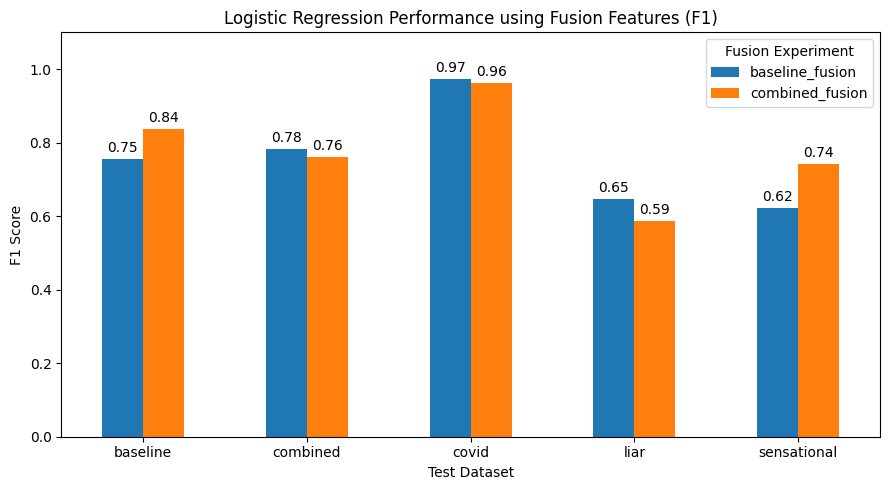

In [ ]:
# =========================
# 12. Visual 1: Fusion F1 by test dataset
# =========================

plot_df = fusion_results_df.copy()

# Optional: focus on Logistic Regression first
plot_df_lr = plot_df[plot_df["fusion_model"] == "Fusion_LogReg"]

pivot_f1 = plot_df_lr.pivot(
    index="test_dataset",
    columns="experiment",
    values="f1"
)

ax = pivot_f1.plot(kind="bar", figsize=(9, 5))
ax.set_title("Logistic Regression Performance using Fusion Features (F1)")
ax.set_ylabel("F1 Score")
ax.set_xlabel("Test Dataset")
ax.set_ylim(0, 1.1) # Adjusted y-axis limit to make top labels visible
plt.xticks(rotation=0)
plt.legend(title="Fusion Experiment")

# Add numbers on top of the bars
for container in ax.containers:
    for i, rect in enumerate(container.patches):
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

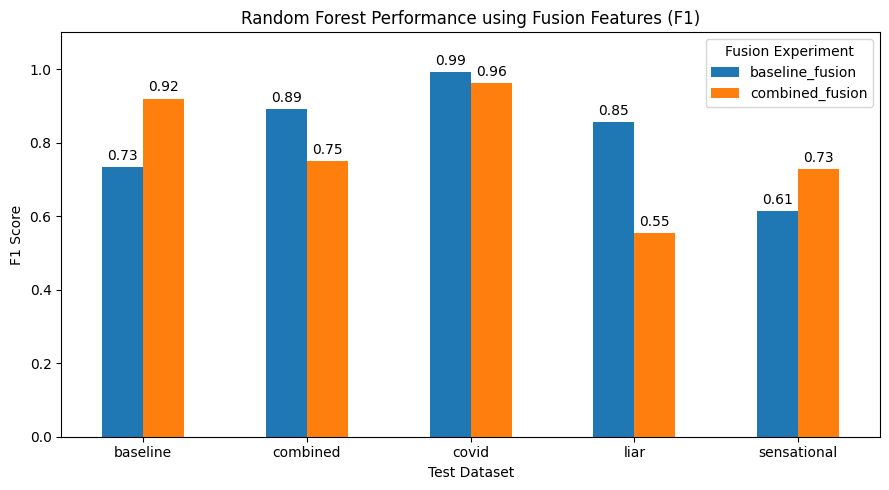

In [ ]:
# =========================
# 12.2. Visual 1: Fusion F1 by test dataset
# =========================

plot_df = fusion_results_df.copy()

plot_df_lr = plot_df[plot_df["fusion_model"] == "Fusion_RF"]

pivot_f1 = plot_df_lr.pivot(
    index="test_dataset",
    columns="experiment",
    values="f1"
)

ax = pivot_f1.plot(kind="bar", figsize=(9, 5))
ax.set_title("Random Forest Performance using Fusion Features (F1)")
ax.set_ylabel("F1 Score")
ax.set_xlabel("Test Dataset")
ax.set_ylim(0, 1.1) # Adjusted y-axis limit to make top labels visible
plt.xticks(rotation=0)
plt.legend(title="Fusion Experiment")

# Add numbers on top of the bars
for container in ax.containers:
    for i, rect in enumerate(container.patches):
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

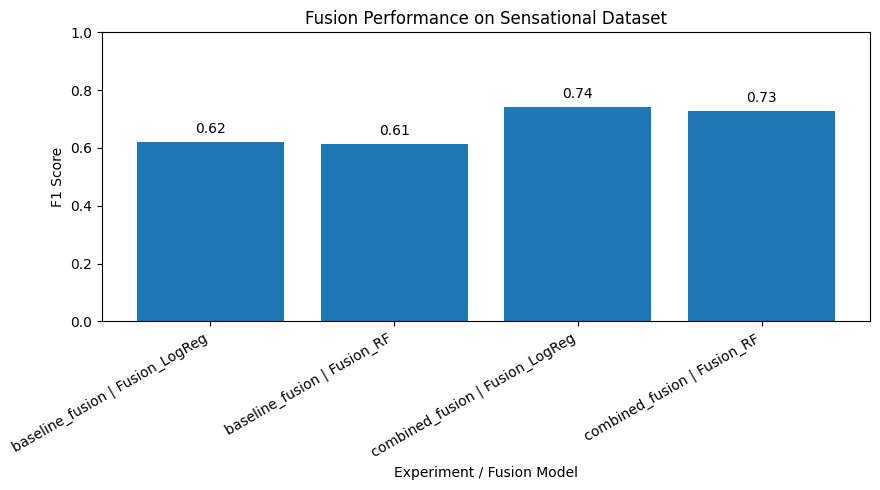

In [ ]:
# =========================
# 13. Visual 2: Sensational improvement focus
# =========================

sensational_df = fusion_results_df[
    fusion_results_df["test_dataset"] == "sensational"
].copy()

labels = sensational_df["experiment"] + " | " + sensational_df["fusion_model"]

plt.figure(figsize=(9, 5))
plt.bar(labels, sensational_df["f1"])
plt.title("Fusion Performance on Sensational Dataset")
plt.ylabel("F1 Score")
plt.xlabel("Experiment / Fusion Model")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")

# Add numbers on top of the bars
for i, f1_score in enumerate(sensational_df["f1"]):
    plt.text(i, f1_score + 0.02, f'{f1_score:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 14. Quick best results summary
# =========================

print("Top Fusion Results by F1:")
display(fusion_results_df.sort_values("f1", ascending=False).head(10))

print("\nFusion Results on Sensational:")
display(
    fusion_results_df[fusion_results_df["test_dataset"] == "sensational"]
    .sort_values("f1", ascending=False)
)

Top Fusion Results by F1:


,experiment,bert_model,train_dataset,test_dataset,fusion_model,train_rows,test_rows,accuracy,precision,recall,f1,tn,fp,fn,tp
5,baseline_fusion,baseline_model,baseline,covid,Fusion_RF,16316,1920,0.993750,0.996390,0.989247,0.992806,1080,3,9,828
4,baseline_fusion,baseline_model,baseline,covid,Fusion_LogReg,16316,1920,0.977083,0.984127,0.962963,0.973430,1070,13,31,806
14,combined_fusion,combined_model,combined,covid,Fusion_LogReg,17281,1920,0.967708,0.975460,0.949821,0.962470,1063,20,42,795
15,combined_fusion,combined_model,combined,covid,Fusion_RF,17281,1920,0.967708,0.977805,0.947431,0.962379,1065,18,44,793
11,combined_fusion,combined_model,combined,baseline,Fusion_RF,17281,4079,0.928414,0.893753,0.947368,0.919780,2113,199,93,1674
3,baseline_fusion,baseline_model,baseline,combined,Fusion_RF,16316,4322,0.900740,0.849545,0.939089,0.892075,2120,314,115,1773
7,baseline_fusion,baseline_model,baseline,liar,Fusion_RF,16316,2160,0.868056,0.811594,0.903226,0.854962,1035,195,90,840
10,combined_fusion,combined_model,combined,baseline,Fusion_LogReg,17281,4079,0.856337,0.826063,0.846633,0.836221,1997,315,271,1496
2,baseline_fusion,baseline_model,baseline,combined,Fusion_LogReg,16316,4322,0.803332,0.756931,0.809852,0.782497,1943,491,359,1529
12,combined_fusion,combined_model,combined,combined,Fusion_LogReg,17281,4322,0.790375,0.758421,0.763242,0.760824,1975,459,447,1441



Fusion Results on Sensational:


,experiment,bert_model,train_dataset,test_dataset,fusion_model,train_rows,test_rows,accuracy,precision,recall,f1,tn,fp,fn,tp
18,combined_fusion,combined_model,combined,sensational,Fusion_LogReg,17281,242,0.723140,0.695652,0.793388,0.741313,79,42,25,96
19,combined_fusion,combined_model,combined,sensational,Fusion_RF,17281,242,0.727273,0.727273,0.727273,0.727273,88,33,33,88
8,baseline_fusion,baseline_model,baseline,sensational,Fusion_LogReg,16316,242,0.462810,0.479821,0.884298,0.622093,5,116,14,107
9,baseline_fusion,baseline_model,baseline,sensational,Fusion_RF,16316,242,0.454545,0.475113,0.867769,0.614035,5,116,16,105




---

Save Model


In [ ]:
# =========================
# Save trained fusion models
# =========================

import joblib

MODEL_OUT_DIR = "/content/drive/MyDrive/Senior_Project/02_Models/Saved_Models"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# Baseline fusion models
joblib.dump(
    baseline_trained_models["Fusion_LogReg"],
    f"{MODEL_OUT_DIR}/baseline_fusion_logreg.joblib"
)

joblib.dump(
    baseline_trained_models["Fusion_RF"],
    f"{MODEL_OUT_DIR}/baseline_fusion_rf.joblib"
)

# Combined fusion models
joblib.dump(
    combined_trained_models["Fusion_LogReg"],
    f"{MODEL_OUT_DIR}/combined_fusion_logreg.joblib"
)

joblib.dump(
    combined_trained_models["Fusion_RF"],
    f"{MODEL_OUT_DIR}/combined_fusion_rf.joblib"
)

print("Fusion models saved.")

Fusion models saved.


In [ ]:
joblib.dump(
    fusion_feature_cols,
    f"{MODEL_OUT_DIR}/fusion_feature_cols.joblib"
)

print("Fusion feature columns saved.")

Fusion feature columns saved.
